In [4]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.3 MB/s eta 0:00:00


In [5]:
import Bio

In [6]:
from Bio import Entrez
from Bio import SeqIO
import pandas as pd

In [7]:
Entrez.email = "bioinfocoach@bioinfo.com"

In [8]:
acc_ids = ['NR_074154.1', 'NR_025816.1', 'NR_074258.1', 'NR_074464.1', 'NR_024570.1', 'NR_024683.1', 'NR_026078.1', 'NR_044709.1', 'NR_112204.1', 'NR_025409.1']

In [9]:
handle = Entrez.efetch(db='nucleotide', id=','.join(acc_ids), rettype='fasta', retmode='text')

In [10]:
record = list(SeqIO.parse(handle, 'fasta'))

In [11]:
for seq_record in record:
  print(f"ID: {seq_record.id}")
  print(f"Description: {seq_record.description}")
  print(f"Sequence: {seq_record.seq}")
  print("\n" + "="*50 + "\n")



ID: NR_074154.1
Description: NR_074154.1 Coxiella burnetii RSA 493 strain RSA 493 16S ribosomal RNA, complete sequence
Sequence: ATTGAAGAGTTTGATTCTGGCTCAGATTGAACGCTAGCGGCATGCTTAACACATGCAAGTCGAACGGCAGCGCGGGGAGCTTGCTCCCTGGCGGCGAGTGGCGGACGGGTGAGTAATGCGTAGGAATCTACCTTGTAGTGGGGGATAACCTGGGGAAACTCGGGCTAATACCGCATAATCTCTTTGGAGCAAAGCGGGGGATCTTCGGACCTCGTGCTATAAGATGAGCCTACGTCGGATTAGCTTGTTGGTGGGGTAATGGCCTACCAAGGCGACGATCCGTAGCTGGTCTGAGAGGACGATCAGCCACACTGGGACTGAGACACGGCCCAGACTCCTACGGGAGGCAGCAGTGGGGAATATTGGACAATGGGGGAAACCCTGATCCAGCAATGCCGCGTGTGTGAAGAAGGCCTTCGGGTTGTAAAGCACTTTCGGTGGGGAAGAAATTCTCAAGGGTAATATCCTTGGGCGTTGACGTTACCCACAGAAGAAGCACTGGCTAACTCTGTGCCAGCAGCCGCGGTAATACAGAGAGTGCAAGCGTTAATCGGAATCACTGGGCGTAAAGCGCGCGTAGGTGGATATTTAAGTCGGATGTGAAAGCCCTGGGCTTAACCTGGGAATTGCACCCGATACTGGGTATCTTGAGTATGGTAGAGGGAAGTGGAATTTCCGGTGTAGCGGTGAAATGCGTAGATATCGGAAAGAACACCAGTGGCGAAGGCGACTTCCTGGACCAATACTGACACTGAGGCGCGAAAGCGTGGGGAGCAAACAGGATTAGAGACCCTGGTAGTCCACGCCGTCAACGATGAGAACTAGCTGTTGGGAAGTTCACTTCTTAGTAGCGAAGCTAACGCGTTAAGTT

In [12]:
output_files = []
for seq_record in record:
    filename = f"{seq_record.id}.fasta"
    with open(filename, "w") as output_handle:
        SeqIO.write(seq_record, output_handle, "fasta")
    output_files.append(filename)
    print(f"Saved {filename}")

print(f"\nAll sequences saved to: {', '.join(output_files)}")

Saved NR_074154.1.fasta
Saved NR_025816.1.fasta
Saved NR_074258.1.fasta
Saved NR_074464.1.fasta
Saved NR_024570.1.fasta
Saved NR_024683.1.fasta
Saved NR_026078.1.fasta
Saved NR_044709.1.fasta
Saved NR_112204.1.fasta
Saved NR_025409.1.fasta

All sequences saved to: NR_074154.1.fasta, NR_025816.1.fasta, NR_074258.1.fasta, NR_074464.1.fasta, NR_024570.1.fasta, NR_024683.1.fasta, NR_026078.1.fasta, NR_044709.1.fasta, NR_112204.1.fasta, NR_025409.1.fasta


In [13]:
print("\n--- Sequence Length ---")

for i, seq_record in enumerate(record):
  print(f"Sequence {i+1} (ID: {seq_record.seq}) : {len(seq_record.seq)} nucleotides")



--- Sequence Length ---
Sequence 1 (ID: ATTGAAGAGTTTGATTCTGGCTCAGATTGAACGCTAGCGGCATGCTTAACACATGCAAGTCGAACGGCAGCGCGGGGAGCTTGCTCCCTGGCGGCGAGTGGCGGACGGGTGAGTAATGCGTAGGAATCTACCTTGTAGTGGGGGATAACCTGGGGAAACTCGGGCTAATACCGCATAATCTCTTTGGAGCAAAGCGGGGGATCTTCGGACCTCGTGCTATAAGATGAGCCTACGTCGGATTAGCTTGTTGGTGGGGTAATGGCCTACCAAGGCGACGATCCGTAGCTGGTCTGAGAGGACGATCAGCCACACTGGGACTGAGACACGGCCCAGACTCCTACGGGAGGCAGCAGTGGGGAATATTGGACAATGGGGGAAACCCTGATCCAGCAATGCCGCGTGTGTGAAGAAGGCCTTCGGGTTGTAAAGCACTTTCGGTGGGGAAGAAATTCTCAAGGGTAATATCCTTGGGCGTTGACGTTACCCACAGAAGAAGCACTGGCTAACTCTGTGCCAGCAGCCGCGGTAATACAGAGAGTGCAAGCGTTAATCGGAATCACTGGGCGTAAAGCGCGCGTAGGTGGATATTTAAGTCGGATGTGAAAGCCCTGGGCTTAACCTGGGAATTGCACCCGATACTGGGTATCTTGAGTATGGTAGAGGGAAGTGGAATTTCCGGTGTAGCGGTGAAATGCGTAGATATCGGAAAGAACACCAGTGGCGAAGGCGACTTCCTGGACCAATACTGACACTGAGGCGCGAAAGCGTGGGGAGCAAACAGGATTAGAGACCCTGGTAGTCCACGCCGTCAACGATGAGAACTAGCTGTTGGGAAGTTCACTTCTTAGTAGCGAAGCTAACGCGTTAAGTTCTCCGCCTGGGGAGTACGGCCGCAAGGTTAAAACTCAAAGAAATTGACGGGGGCCCGCACAAGCGGTGGAGCATGTGGTTTAATTCGA

In [14]:
print("n\--- GC Content ---")
for i, seq_record in enumerate(record):
  seq = str(seq_record.seq).upper()
  g_count = seq.count('G')
  c_count = seq.count('C')
  total_bases = len(seq)

  if total_bases > 0 :
    gc_percentage = ((g_count + c_count) / total_bases) * 100
    print(f"Sequence {i+1}: (ID: {seq_record.id}) GC% = {gc_percentage:.2f}%")
  else:
    print(f"Sequence {i+1}: ID: {seq_record.id}: No Sequence Data to Calculate GC%")



n\--- GC Content ---
Sequence 1: (ID: NR_074154.1) GC% = 53.81%
Sequence 2: (ID: NR_025816.1) GC% = 54.10%
Sequence 3: (ID: NR_074258.1) GC% = 64.82%
Sequence 4: (ID: NR_074464.1) GC% = 49.73%
Sequence 5: (ID: NR_024570.1) GC% = 54.62%
Sequence 6: (ID: NR_024683.1) GC% = 51.87%
Sequence 7: (ID: NR_026078.1) GC% = 54.07%
Sequence 8: (ID: NR_044709.1) GC% = 49.40%
Sequence 9: (ID: NR_112204.1) GC% = 55.45%
Sequence 10: (ID: NR_025409.1) GC% = 54.71%


<>:1: SyntaxWarning: invalid escape sequence '\-'
<>:1: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_3684/2217716157.py:1: SyntaxWarning: invalid escape sequence '\-'
  print("n\--- GC Content ---")


In [15]:
print("\n--- Nucleotide Count ---")
for i, seq_record in enumerate(record):
  seq = str(seq_record.seq).upper()

  a_count = seq.count('A')
  c_count = seq.count('C')
  t_count = seq.count('T')
  g_count = seq.count('G')

  print(f"Sequence {i+1} (ID: {seq_record.id}) : ")
  print(f"A: {a_count}")
  print(f"C: {c_count}")
  print(f"T: {t_count}")
  print(f"G: {g_count}")
  print("\n" + "="*50 + "\n")


--- Nucleotide Count ---
Sequence 1 (ID: NR_074154.1) : 
A: 365
C: 325
T: 308
G: 459


Sequence 2 (ID: NR_025816.1) : 
A: 360
C: 335
T: 301
G: 444


Sequence 3 (ID: NR_074258.1) : 
A: 292
C: 426
T: 228
G: 532


Sequence 4 (ID: NR_074464.1) : 
A: 409
C: 312
T: 349
G: 438


Sequence 5 (ID: NR_024570.1) : 
A: 366
C: 329
T: 289
G: 463


Sequence 6 (ID: NR_024683.1) : 
A: 395
C: 324
T: 313
G: 439


Sequence 7 (ID: NR_026078.1) : 
A: 392
C: 351
T: 314
G: 480


Sequence 8 (ID: NR_044709.1) : 
A: 401
C: 318
T: 336
G: 425


Sequence 9 (ID: NR_112204.1) : 
A: 363
C: 354
T: 294
G: 470


Sequence 10 (ID: NR_025409.1) : 
A: 373
C: 352
T: 300
G: 461




In [16]:
the_results = []
for i, seq_record in enumerate(record):
  seq = str(seq_record.seq).upper()
  total_bases = len(seq)
  a_count = seq.count('A')
  c_count = seq.count('C')
  t_count = seq.count('T')
  g_count = seq.count('G')

  gc_percentage = 0.0
  if total_bases > 0:
    gc_percentage = ((g_count + c_count) / total_bases) * 100

  the_results.append({
      'Sequence ID': seq_record.id,
      'Sequence Length': total_bases,
      'GC Content': round(gc_percentage, 2),
      'A Count': a_count,
      'C Count': c_count,
      'T Count': t_count,
      'G Count': g_count
  })

df_results = pd.DataFrame(the_results)
display(df_results)

,Sequence ID,Sequence Length,GC Content,A Count,C Count,T Count,G Count
0,NR_074154.1,1457,53.81,365,325,308,459
1,NR_025816.1,1440,54.10,360,335,301,444
2,NR_074258.1,1478,64.82,292,426,228,532
3,NR_074464.1,1508,49.73,409,312,349,438
4,NR_024570.1,1450,54.62,366,329,289,463
5,NR_024683.1,1471,51.87,395,324,313,439
6,NR_026078.1,1537,54.07,392,351,314,480
7,NR_044709.1,1504,49.40,401,318,336,425
8,NR_112204.1,1486,55.45,363,354,294,470
9,NR_025409.1,1486,54.71,373,352,300,461


In [17]:
df_results.head()

,Sequence ID,Sequence Length,GC Content,A Count,C Count,T Count,G Count
0,NR_074154.1,1457,53.81,365,325,308,459
1,NR_025816.1,1440,54.10,360,335,301,444
2,NR_074258.1,1478,64.82,292,426,228,532
3,NR_074464.1,1508,49.73,409,312,349,438
4,NR_024570.1,1450,54.62,366,329,289,463


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df_results.to_csv('sequence_analysis_results.csv', index=False)

/tmp/ipykernel_3684/2618156727.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sequence ID', y='GC Content', data=df_results, palette='viridis')


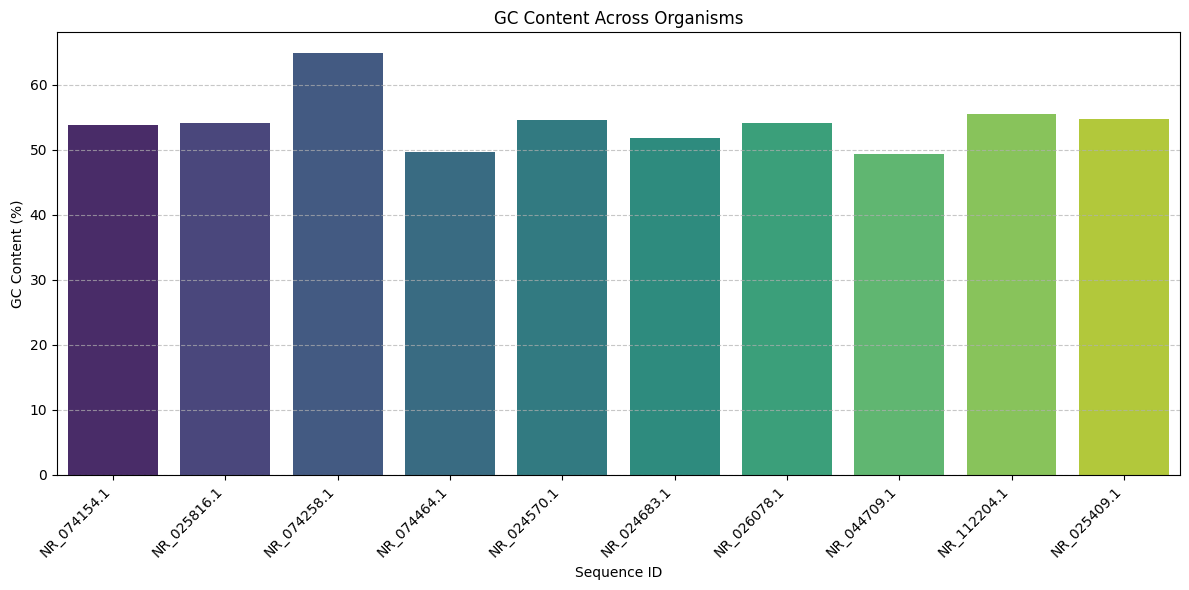

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Sequence ID', y='GC Content', data=df_results, palette='viridis')
plt.title('GC Content Across Organisms')
plt.xlabel('Sequence ID')
plt.ylabel('GC Content (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
organism_names = [
    "Buchnera aphidicola",
    "Borrelia burgdorferi",
    "Clostridium perfringens",
    "Bacteroides fragilis",
    "Escherichia coli",
    "Bacillus subtilis",
    "Pseudomonas aeruginosa",
    "Bifidobacterium longum",
    "Mycobacterium tuberculosis",
    "Streptomyces coelicolor"
]

df_results['Organism Name'] = organism_names

display(df_results.head())

,Sequence ID,Sequence Length,GC Content,A Count,C Count,T Count,G Count,Organism Name
0,NR_074154.1,1457,53.81,365,325,308,459,Buchnera aphidicola
1,NR_025816.1,1440,54.10,360,335,301,444,Borrelia burgdorferi
2,NR_074258.1,1478,64.82,292,426,228,532,Clostridium perfringens
3,NR_074464.1,1508,49.73,409,312,349,438,Bacteroides fragilis
4,NR_024570.1,1450,54.62,366,329,289,463,Escherichia coli


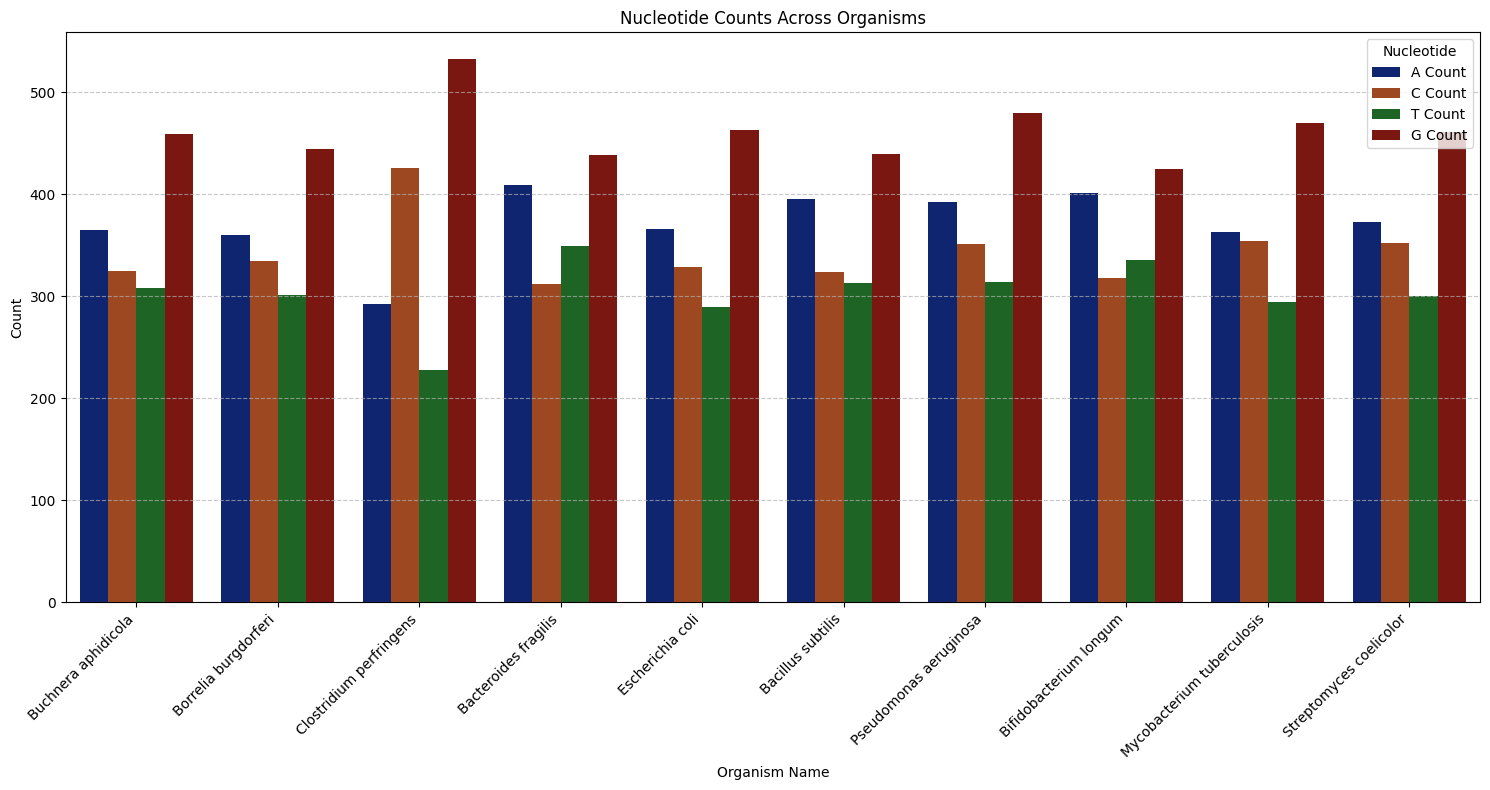

In [40]:
# Melt the DataFrame to long format for easier plotting of nucleotide counts
df_nucleotide_counts = df_results.melt(id_vars=['Organism Name', 'Sequence ID'],
                                       value_vars=['A Count', 'C Count', 'T Count', 'G Count'],
                                       var_name='Nucleotide Type',
                                       value_name='Count')

plt.figure(figsize=(15, 8))
sns.barplot(x='Organism Name', y='Count', hue='Nucleotide Type', data=df_nucleotide_counts, palette='dark')
plt.title('Nucleotide Counts Across Organisms')
plt.xlabel('Organism Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nucleotide')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('nucleotide_counts_organisms.png')
plt.show()

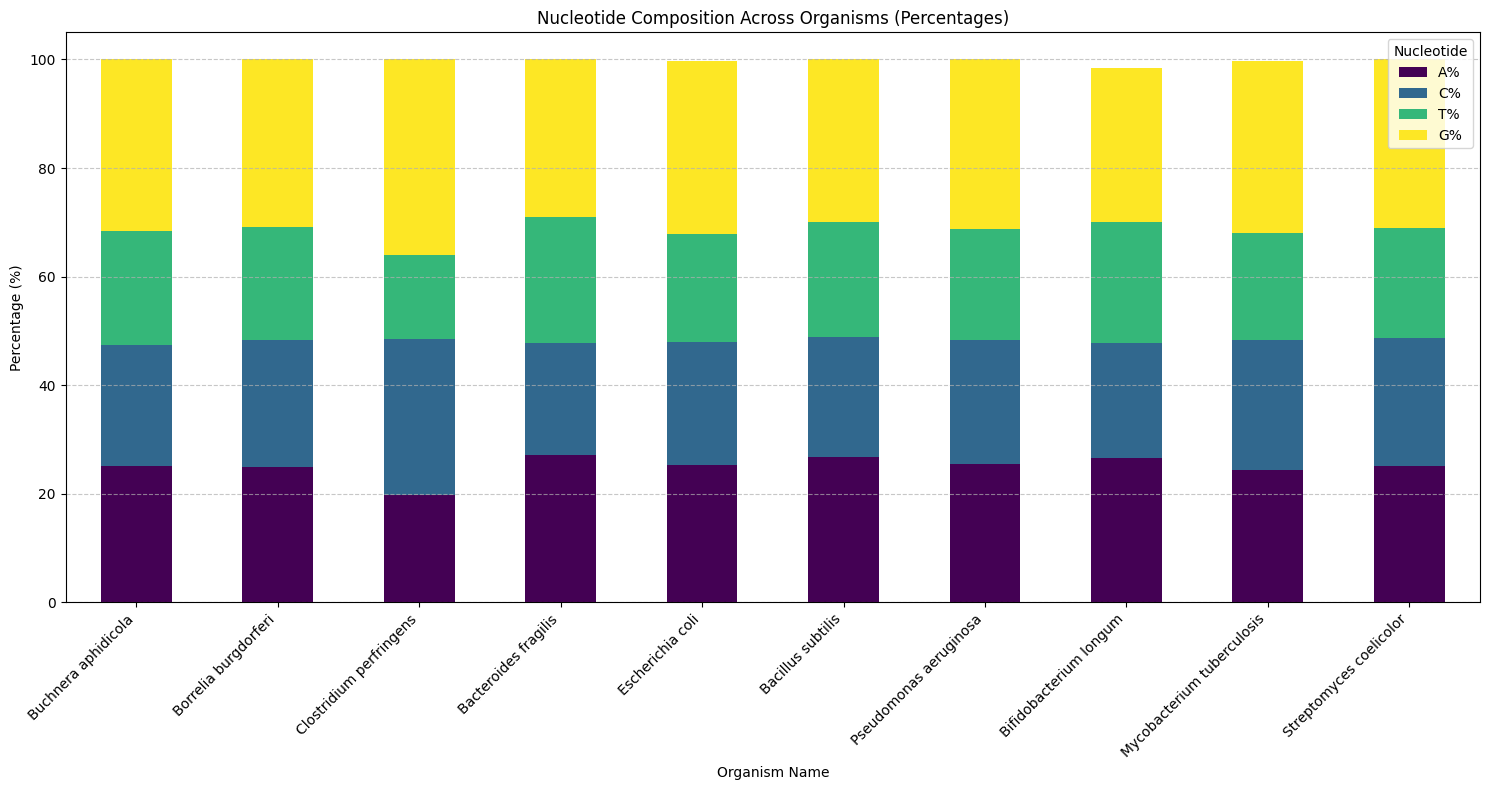

In [33]:
import matplotlib.pyplot as plt

# Calculate the percentage of each nucleotide
df_results['A%'] = (df_results['A Count'] / df_results['Sequence Length']) * 100
df_results['C%'] = (df_results['C Count'] / df_results['Sequence Length']) * 100
df_results['T%'] = (df_results['T Count'] / df_results['Sequence Length']) * 100
df_results['G%'] = (df_results['G Count'] / df_results['Sequence Length']) * 100

# Create a new DataFrame for percentages, setting 'Organism Name' as index for easier plotting
df_percentages = df_results[['Organism Name', 'A%', 'C%', 'T%', 'G%']].set_index('Organism Name')

# Plotting
fig, ax = plt.subplots(figsize=(15, 8))
df_percentages[['A%', 'C%', 'T%', 'G%']].plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

ax.set_title('Nucleotide Composition Across Organisms (Percentages)')
ax.set_xlabel('Organism Name')
ax.set_ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nucleotide')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('nucleotide_composition_percentages.png') # Save the plot as a PNG file
plt.show()

/tmp/ipykernel_3684/3201423141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Organism Name', y='GC Content', data=df_results, palette='viridis')


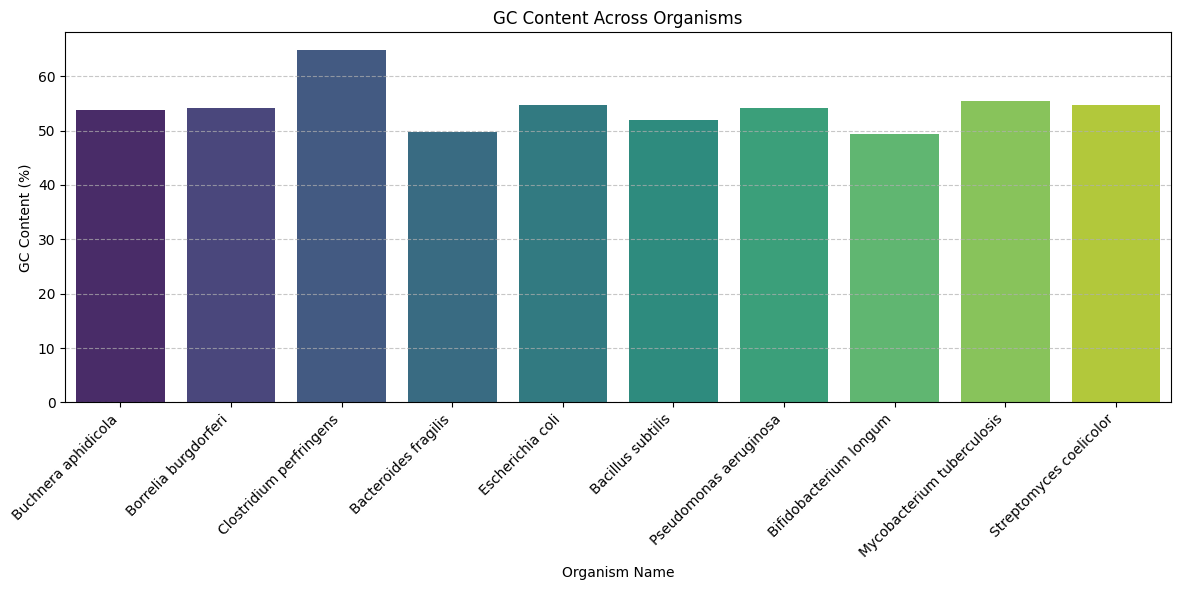

In [37]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Organism Name', y='GC Content', data=df_results, palette='viridis')
plt.title('GC Content Across Organisms')
plt.xlabel('Organism Name')
plt.ylabel('GC Content (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('gc_content_organisms.png')
plt.show()